# 1 · Quickstart

An end-to-end pass through `nextaire_tools` on synthetic hourly air-quality data: load,
clean and engineer features in a pipeline, explore, and fit a model with a
leakage-free time-series split. No network or accounts required.

In [1]:
import sys, pathlib
# Reuse the synthetic data generators that ship with the reproductions.
sys.path.insert(0, str(pathlib.Path.cwd().parent / "reproductions"))

%matplotlib inline
import matplotlib.pyplot as plt

import nextaire_tools
from _synthetic import make_graz_hourly

print("nextaire_tools", nextaire_tools.__version__)

nextaire_tools 0.1.0


## Example data

A single synthetic Graz-style station: hourly pollutants + meteorology, with gaps and spikes.

In [2]:
df = make_graz_hourly(n_days=180, seed=0)
df = df[["no2", "o3", "pm10", "temp", "rh", "wind_speed", "wind_dir", "blh"]]
print(df.shape)
df.head()

(4320, 8)


,no2,o3,pm10,temp,rh,wind_speed,wind_dir,blh
timestamp,,,,,,,,
2016-01-01 00:00:00,10.164599,30.806060,439.673141,15.904661,67.577391,4.458159,119.798347,218.189251
2016-01-01 01:00:00,7.479924,27.111634,34.978719,15.593436,88.024079,5.088861,177.414812,146.450701
2016-01-01 02:00:00,9.678561,40.474389,36.042722,17.737894,84.600186,3.619021,245.824223,310.311027
2016-01-01 03:00:00,3.504186,34.897785,38.188958,17.620360,79.163304,3.938121,234.123550,618.681456
2016-01-01 04:00:00,24.015405,36.743402,44.342934,17.581862,79.408209,3.867481,231.778382,610.222797


## Load & save

`load_table` / `save_table` round-trip CSV, Excel, and Parquet while keeping the datetime index.

In [3]:
from nextaire_tools import load_table, save_table

save_table(df, "station.parquet")
reloaded = load_table("station.parquet")
print(type(reloaded.index).__name__, reloaded.shape)
reloaded.head(3)

DatetimeIndex (4320, 8)


,no2,o3,pm10,temp,rh,wind_speed,wind_dir,blh
timestamp,,,,,,,,
2016-01-01 00:00:00,10.164599,30.806060,439.673141,15.904661,67.577391,4.458159,119.798347,218.189251
2016-01-01 01:00:00,7.479924,27.111634,34.978719,15.593436,88.024079,5.088861,177.414812,146.450701
2016-01-01 02:00:00,9.678561,40.474389,36.042722,17.737894,84.600186,3.619021,245.824223,310.311027


## Explore

Quick EDA with the built-in, colorblind-safe theme.

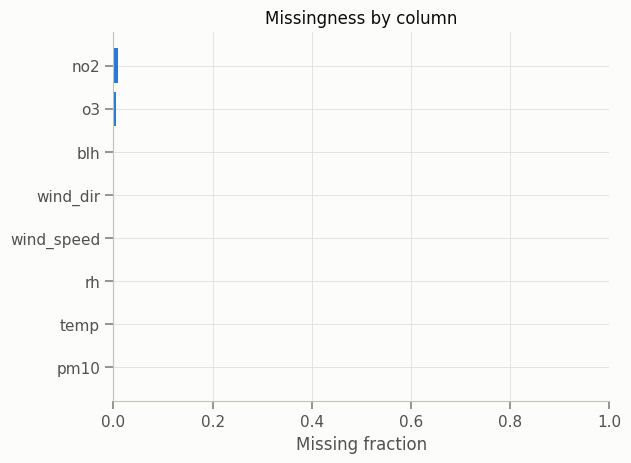

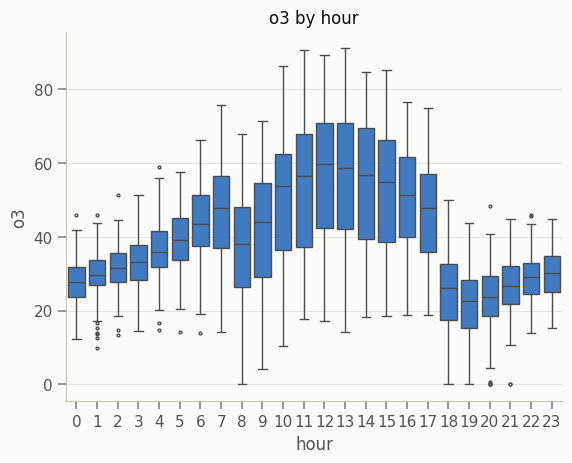

In [4]:
from nextaire_tools.viz import plot_missingness, plot_seasonality

plot_missingness(df)
plt.show()

plot_seasonality(df, column="o3", by="hour")
plt.show()

## Clean & engineer in a pipeline

Every step is a DataFrame-in/DataFrame-out transformer, so column names and the
`DatetimeIndex` survive the whole pipeline.

In [5]:
from nextaire_tools import Pipeline
from nextaire_tools.preprocessing import MissingValueHandler, OutlierHandler, TemporalFeatures, Scaler

pipe = Pipeline([
    MissingValueHandler(strategy="interpolate", limit=3),
    OutlierHandler(columns=["no2", "o3", "pm10"], method="iqr", strategy="clip"),
    TemporalFeatures(
        add=("hour", "dayofweek", "month", "is_weekend"),
        cyclical=("hour", "dayofweek", "dayofyear"),
    ),
    Scaler(method="standard"),
])
clean = pipe.fit_transform(df)
print("clean shape:", clean.shape)
clean.head(3)

clean shape: (4320, 18)


,no2,o3,pm10,temp,rh,wind_speed,wind_dir,blh,hour,dayofweek,month,is_weekend,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,dayofyear_sin,dayofyear_cos
timestamp,,,,,,,,,,,,,,,,,,
2016-01-01 00:00:00,-0.973941,-0.526011,2.778341,0.411128,-0.192295,0.411968,-2.340288,-1.605578,-1.661325,0.494825,-1.456123,-0.637377,2.558669e-17,1.414214,-0.603038,-1.282051,-2.143229,1.396512
2016-01-01 01:00:00,-1.181691,-0.752111,0.175699,0.377914,1.360426,1.000431,-1.188416,-1.872427,-1.516862,0.494825,-1.456123,-0.637377,3.660254e-01,1.366025,-0.603038,-1.282051,-2.143229,1.396512
2016-01-01 02:00:00,-1.011553,0.065693,0.292401,0.606775,1.100416,-0.370969,0.179229,-1.262910,-1.372399,0.494825,-1.456123,-0.637377,7.071068e-01,1.224745,-0.603038,-1.282051,-2.143229,1.396512


## Model with a correct time-series split

`BlockingTimeSeriesSplit` keeps folds chronological so no future information
leaks into training. `cross_val_report` tabulates held-out metrics per fold.

In [6]:
from nextaire_tools.models import make_regressor, cross_val_report, BlockingTimeSeriesSplit

target = "no2"
X = clean.drop(columns=[target])
y = clean[target]

model = make_regressor("random_forest", n_estimators=200)
report = cross_val_report(model, X, y, cv=BlockingTimeSeriesSplit(n_splits=4))
report.round(3)

,mae,mse,rmse,r2,mape,smape,wape,nmae,nrmse,bias,pearson_r,spearman_r,index_of_agreement,fac2
fold,,,,,,,,,,,,,,
0,0.390,0.246,0.496,0.765,197.802,80.656,0.479,0.285,0.363,-0.008,0.875,0.852,0.927,0.578
1,0.403,0.253,0.503,0.753,833.497,80.395,0.493,0.281,0.351,-0.099,0.874,0.861,0.924,0.567
2,0.416,0.274,0.523,0.705,206.573,81.707,0.538,0.317,0.398,-0.035,0.841,0.829,0.904,0.543
3,0.396,0.255,0.505,0.753,122.170,75.254,0.484,0.280,0.358,-0.012,0.868,0.851,0.924,0.593
mean,0.401,0.257,0.507,0.744,340.010,79.503,0.498,0.291,0.368,-0.039,0.864,0.848,0.920,0.570
std,0.011,0.012,0.012,0.027,331.166,2.889,0.027,0.017,0.021,0.042,0.016,0.014,0.011,0.021


## Inspect predictions on a hold-out year-block

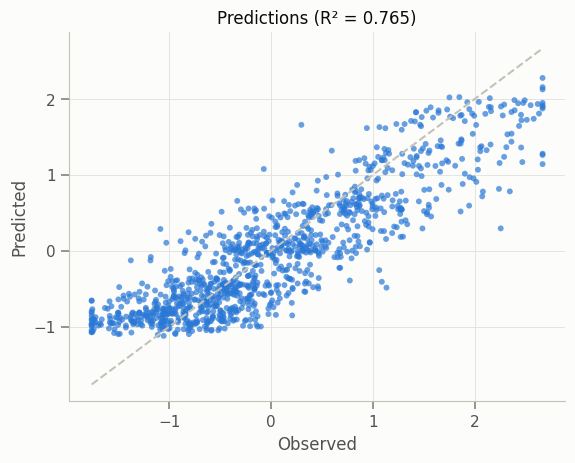

In [7]:
from nextaire_tools.models import temporal_train_test_split
from nextaire_tools.viz import plot_predictions

train, test = temporal_train_test_split(clean, test_size=0.25)
model.fit(train.drop(columns=[target]), train[target])
pred = model.predict(test.drop(columns=[target]))

plot_predictions(test[target].to_numpy(), pred)
plt.show()

Next: **[2 · Preprocessing & feature tour](02_preprocessing_and_features.ipynb)**
for each transformer in detail, or
**[3 · Reproducing the papers](03_reproduce_papers.ipynb)**.